M2: mu ~ N(3, I), y|mu ~ N(mu, I)
with MMD summary space regularization
D=20, N=100, S=4D

In [1]:
import numpy as np
import bayesflow as bf
import keras
from pathlib import Path

INFO:bayesflow:Using backend 'tensorflow'


In [2]:
from tqdm.auto import tqdm as original_tqdm
import bayesflow.approximators.helpers.samplers as bf_samplers
import bayesflow.approximators.helpers.conditions as bf_conditions


def quiet_tqdm(*args, **kwargs):
    kwargs["disable"] = True
    return original_tqdm(*args, **kwargs)


bf_samplers.tqdm = quiet_tqdm
bf_conditions.tqdm = quiet_tqdm

In [3]:
RNG = np.random.default_rng(2025)
num_dims = 20
num_obs = 100
mu_prior_mean = 3
mu_prior_std = 1
likelihood_std = 1

In [4]:
# simulator
def prior(mu=mu_prior_mean, sigma=mu_prior_std):
    mu = RNG.normal(loc=mu, scale=sigma, size=num_dims)
    return dict(mu=mu)


def likelihood(mu):
    x = RNG.normal(loc=mu, scale=likelihood_std, size=(num_obs, num_dims))
    return dict(x=x)


simulator = bf.make_simulator([prior, likelihood])

In [5]:
# adapter
adapter = (
    bf.adapters.Adapter()
    .convert_dtype("float64", "float32")
    .rename("mu", "inference_variables")
    .rename("x", "summary_variables")
)

In [6]:
# networks
summary_net = bf.networks.DeepSet(summary_dim=4 * num_dims, base_distribution="normal")

inference_net = bf.networks.CouplingFlow()

In [7]:
workflow = bf.BasicWorkflow(
    simulator=simulator,
    adapter=adapter,
    summary_network=summary_net,
    inference_network=inference_net,
    standardize="all",
)
epochs = 100
batch_size = 64
num_batches_per_epoch = 128
learning_rate = keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-4, decay_steps=epochs * num_batches_per_epoch
)
workflow.approximator.compile(
    optimizer=keras.optimizers.Adam(learning_rate=learning_rate)
)

In [8]:
history = workflow.fit_online(
    epochs=epochs, batch_size=batch_size, num_batches_per_epoch=num_batches_per_epoch
)

INFO:bayesflow:Fitting on dataset instance of OnlineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 27s 96ms/step - CouplingFlow/loss: 25.8615 - DeepSet/loss: 0.3436 - loss: 26.2051
Epoch 2/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 13s 100ms/step - CouplingFlow/loss: 14.1164 - DeepSet/loss: 0.3445 - loss: 14.4608
Epoch 3/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 14s 104ms/step - CouplingFlow/loss: 5.2974 - DeepSet/loss: 0.3697 - loss: 5.6671
Epoch 4/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 14s 106ms/step - CouplingFlow/loss: 0.5034 - DeepSet/loss: 0.3691 - loss: 0.8725
Epoch 5/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 14s 107ms/step - CouplingFlow/loss: -2.5373 - DeepSet/loss: 0.3398 - loss: -2.1975
Epoch 6/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 13s 105ms/step - CouplingFlow/loss: -4.8248 - DeepSet/loss: 0.3157 - loss: -4.5091
Epoch 7/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 14s 113ms/step - CouplingFlow/loss: -6.8235 - DeepSet/loss: 0.3033 - loss: -6.5201
Epoch 8/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 15s 113ms/step - CouplingFlow/loss: -8.4357 - DeepSet/loss: 0.2939 - loss: -8.1418
Epoch 9/100
1

INFO:bayesflow:Training completed in 46.46 minutes.


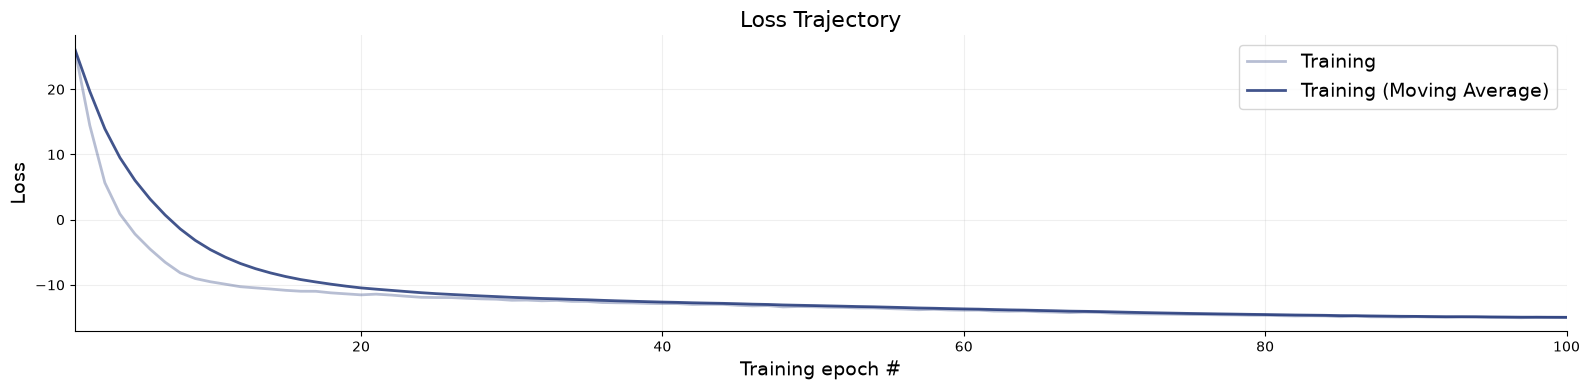

In [9]:
f = bf.diagnostics.plots.loss(history)

In [10]:
# Generate test datasets and get posterior samples and perform diagnostics
num_samples = 1000  # number of posterior samples
val_sims = simulator.sample(200)  # validation data
post_draws = workflow.sample(conditions=val_sims, num_samples=num_samples)
post_draws.keys()

INFO:bayesflow:Sampling completed in 1.05 seconds.


dict_keys(['mu'])

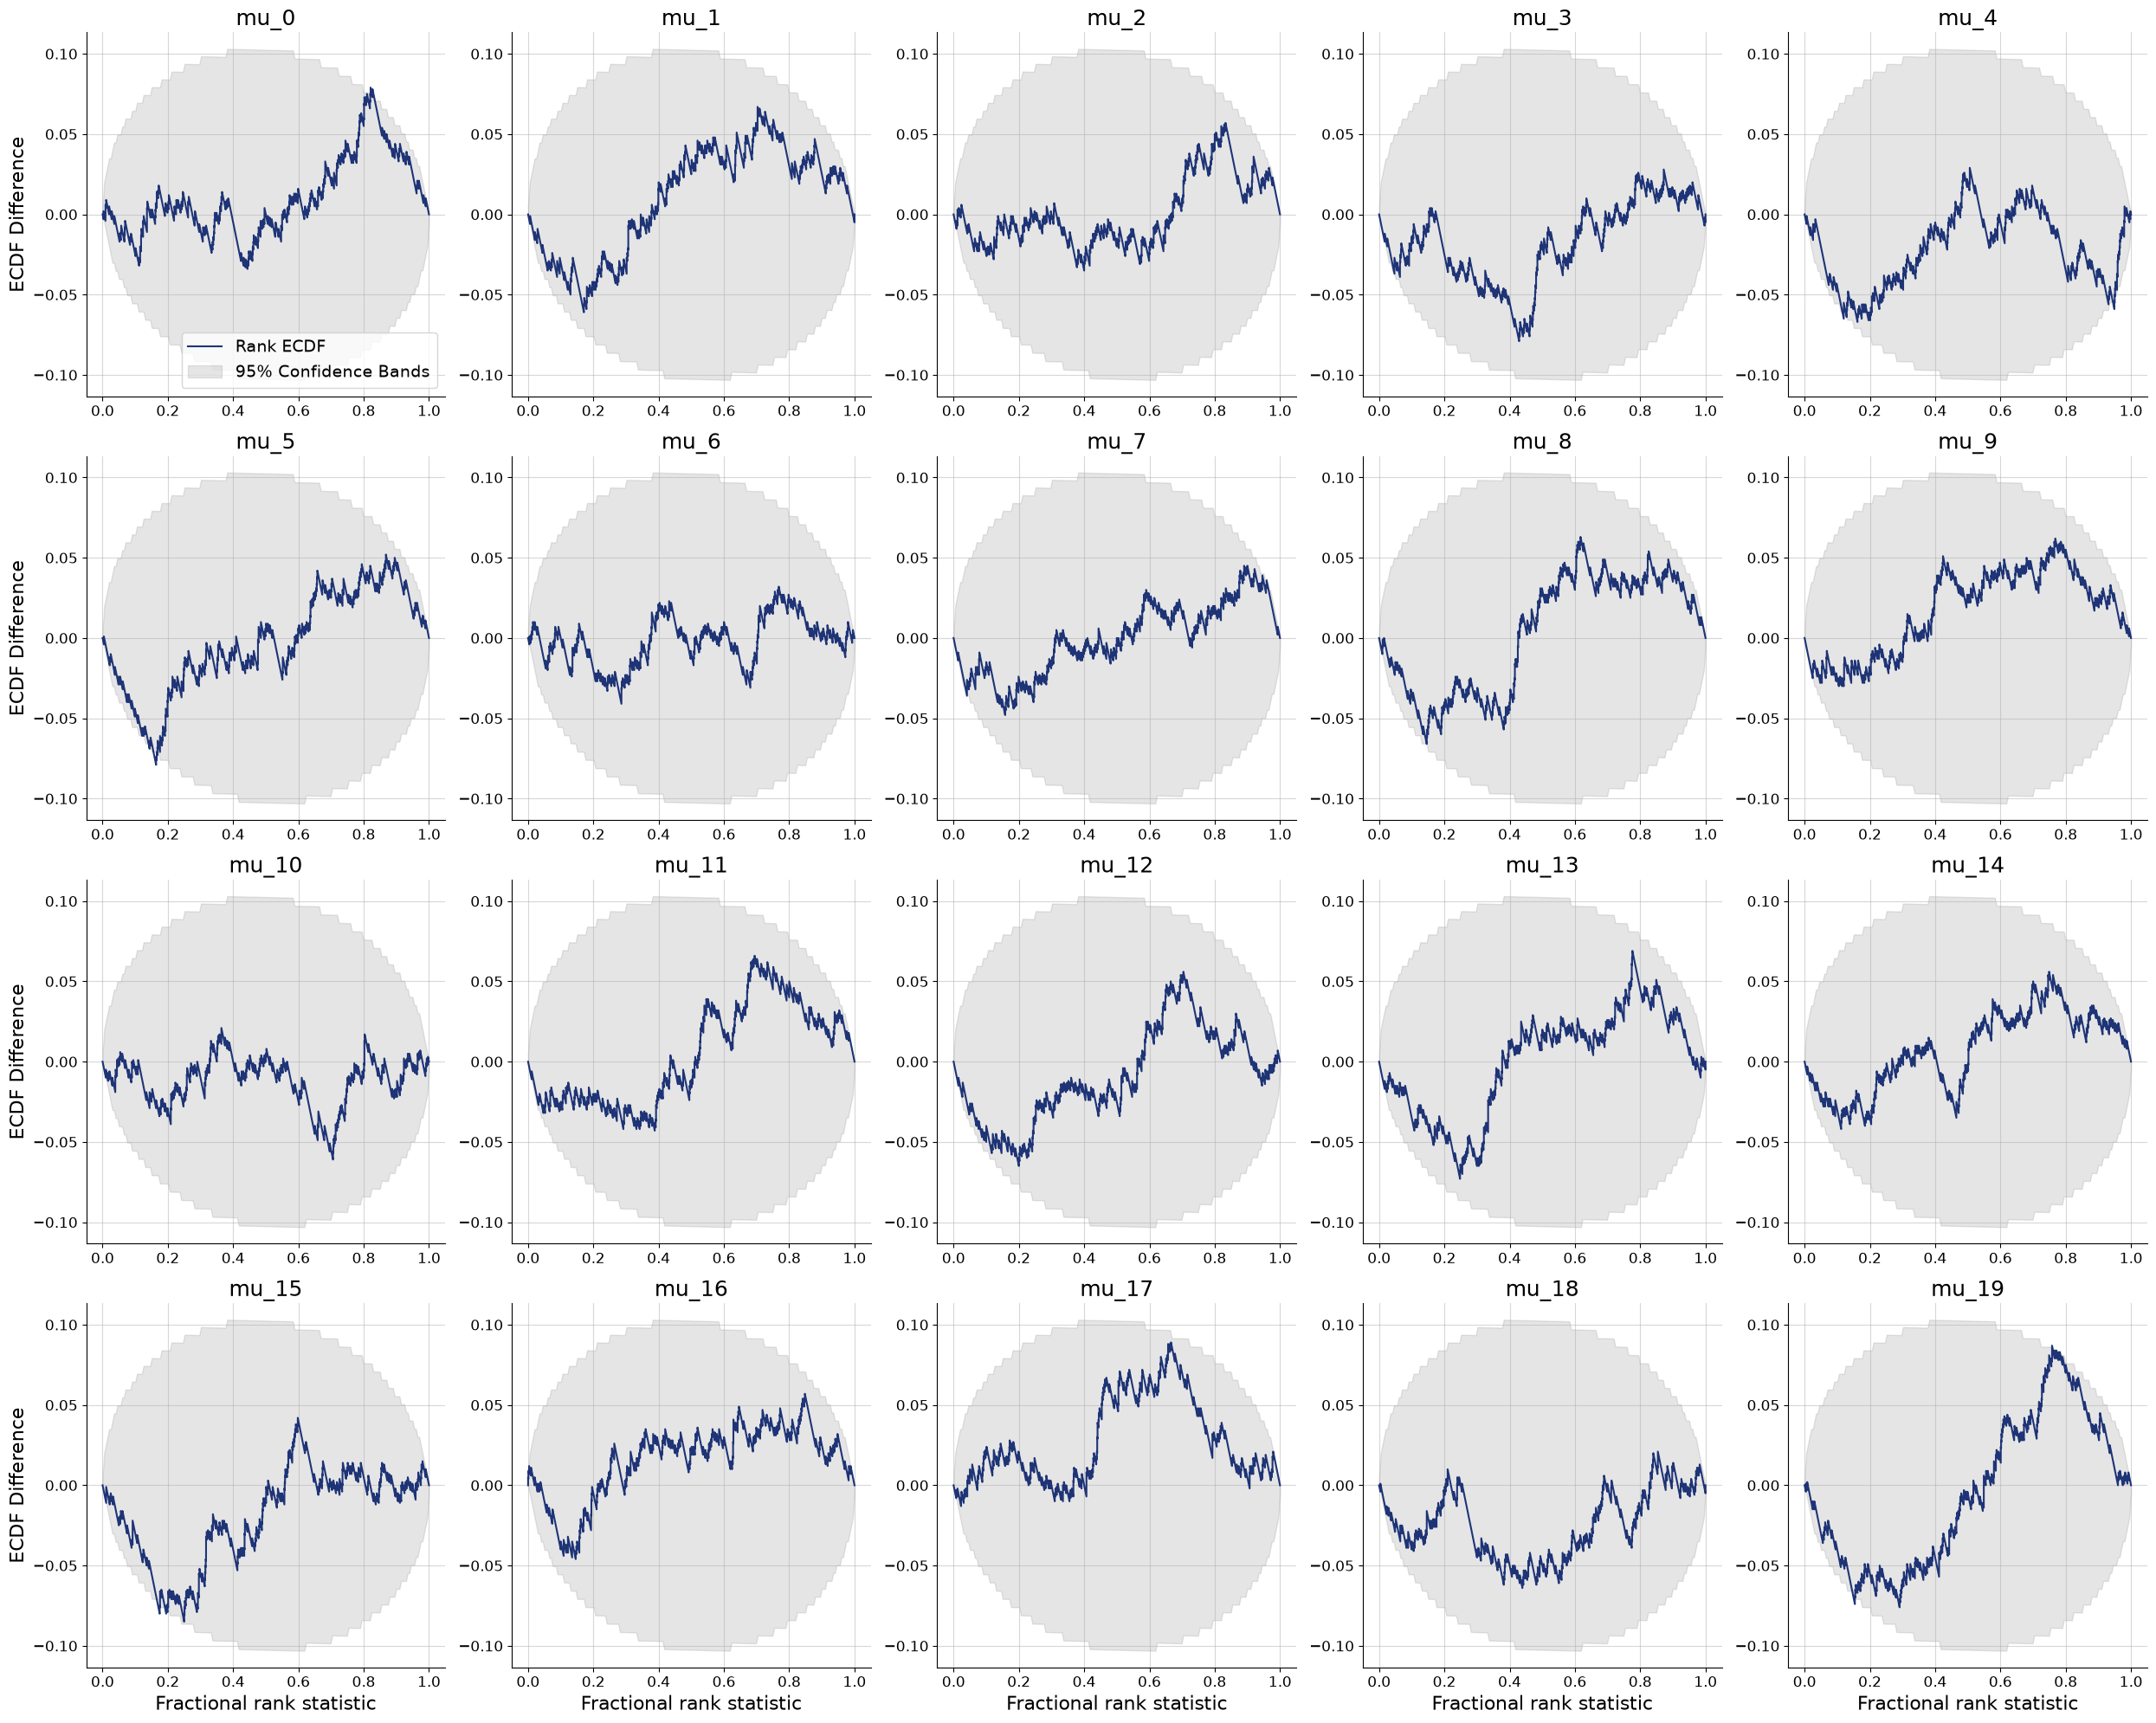

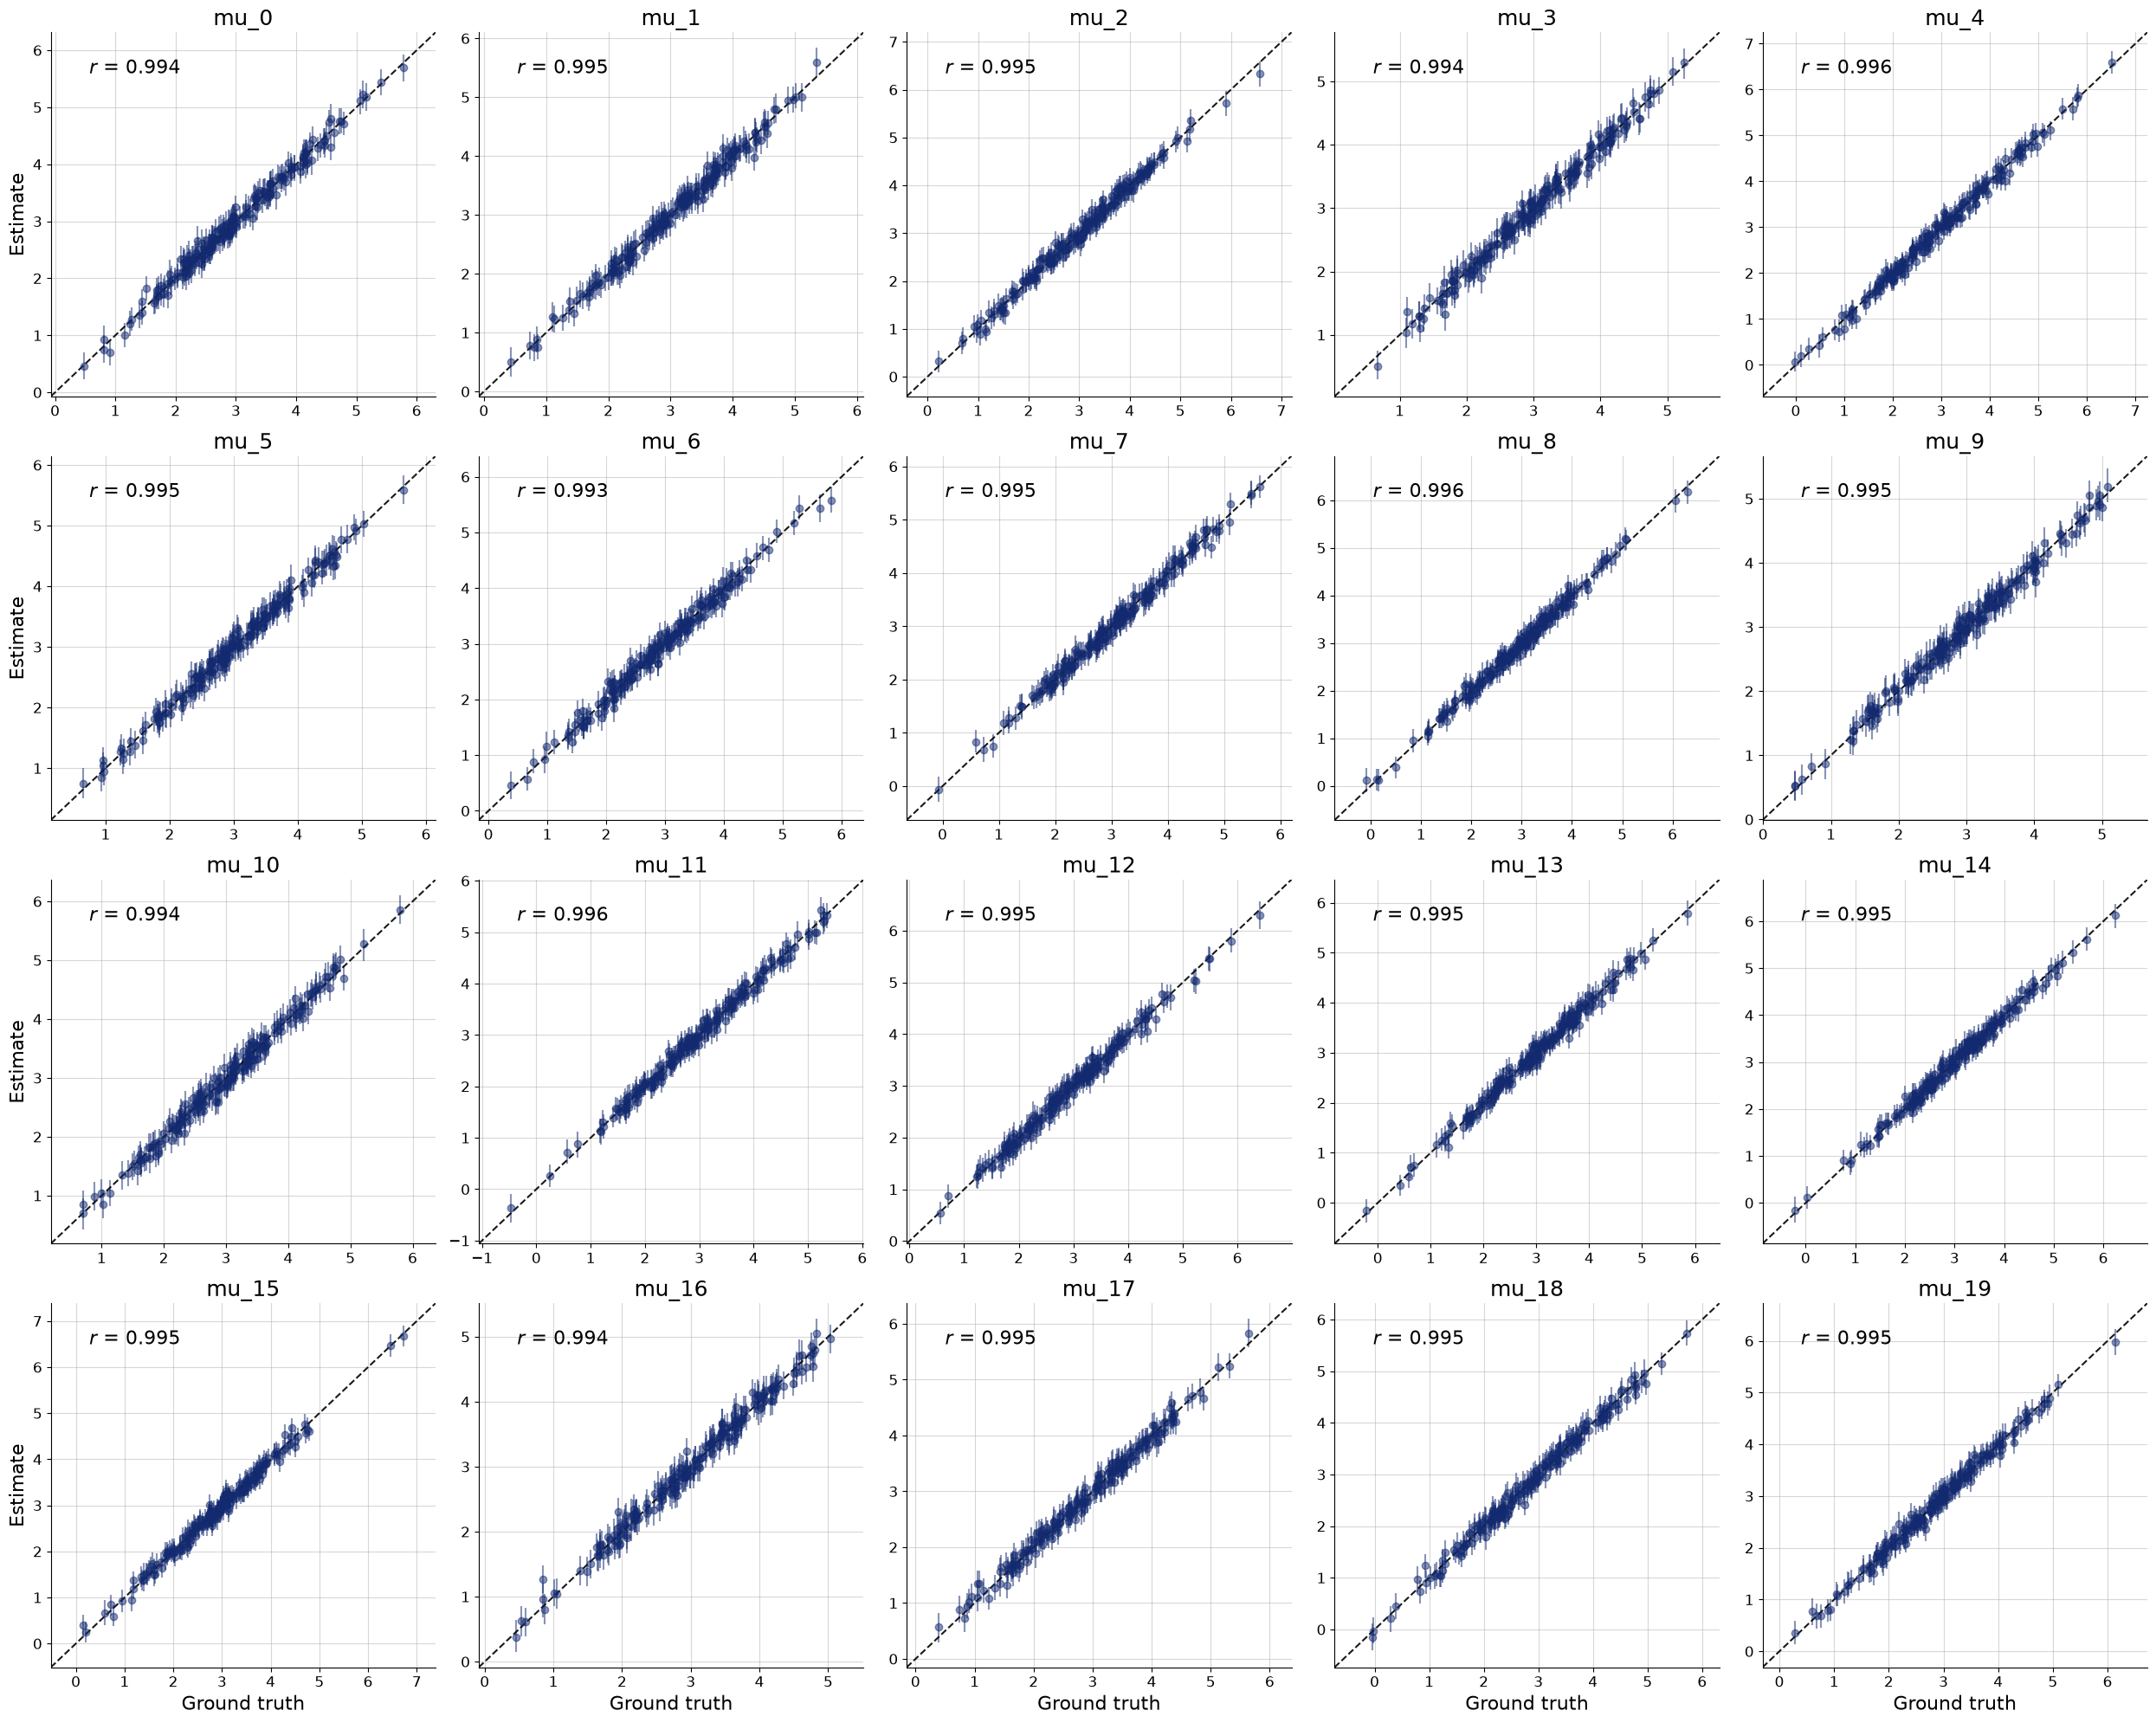

In [11]:
# f1 = bf.diagnostics.plots.calibration_histogram(post_draws, val_sims)
f2 = bf.diagnostics.plots.calibration_ecdf(post_draws, val_sims, difference=True)
f3 = bf.diagnostics.plots.recovery(post_draws, val_sims)

In [12]:
# Save the trained approximator
filepath = (
    Path(
        "/Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/gaussian/networks"
    )
    / "m2_s_80d_100n.keras"
)
filepath.parent.mkdir(exist_ok=True)
workflow.approximator.save(filepath=filepath)

In [13]:
# load approximator
filepath = (
    Path(
        "/Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/gaussian/networks"
    )
    / "m2_s_80d_100n.keras"
)
approximator = keras.saving.load_model(filepath)

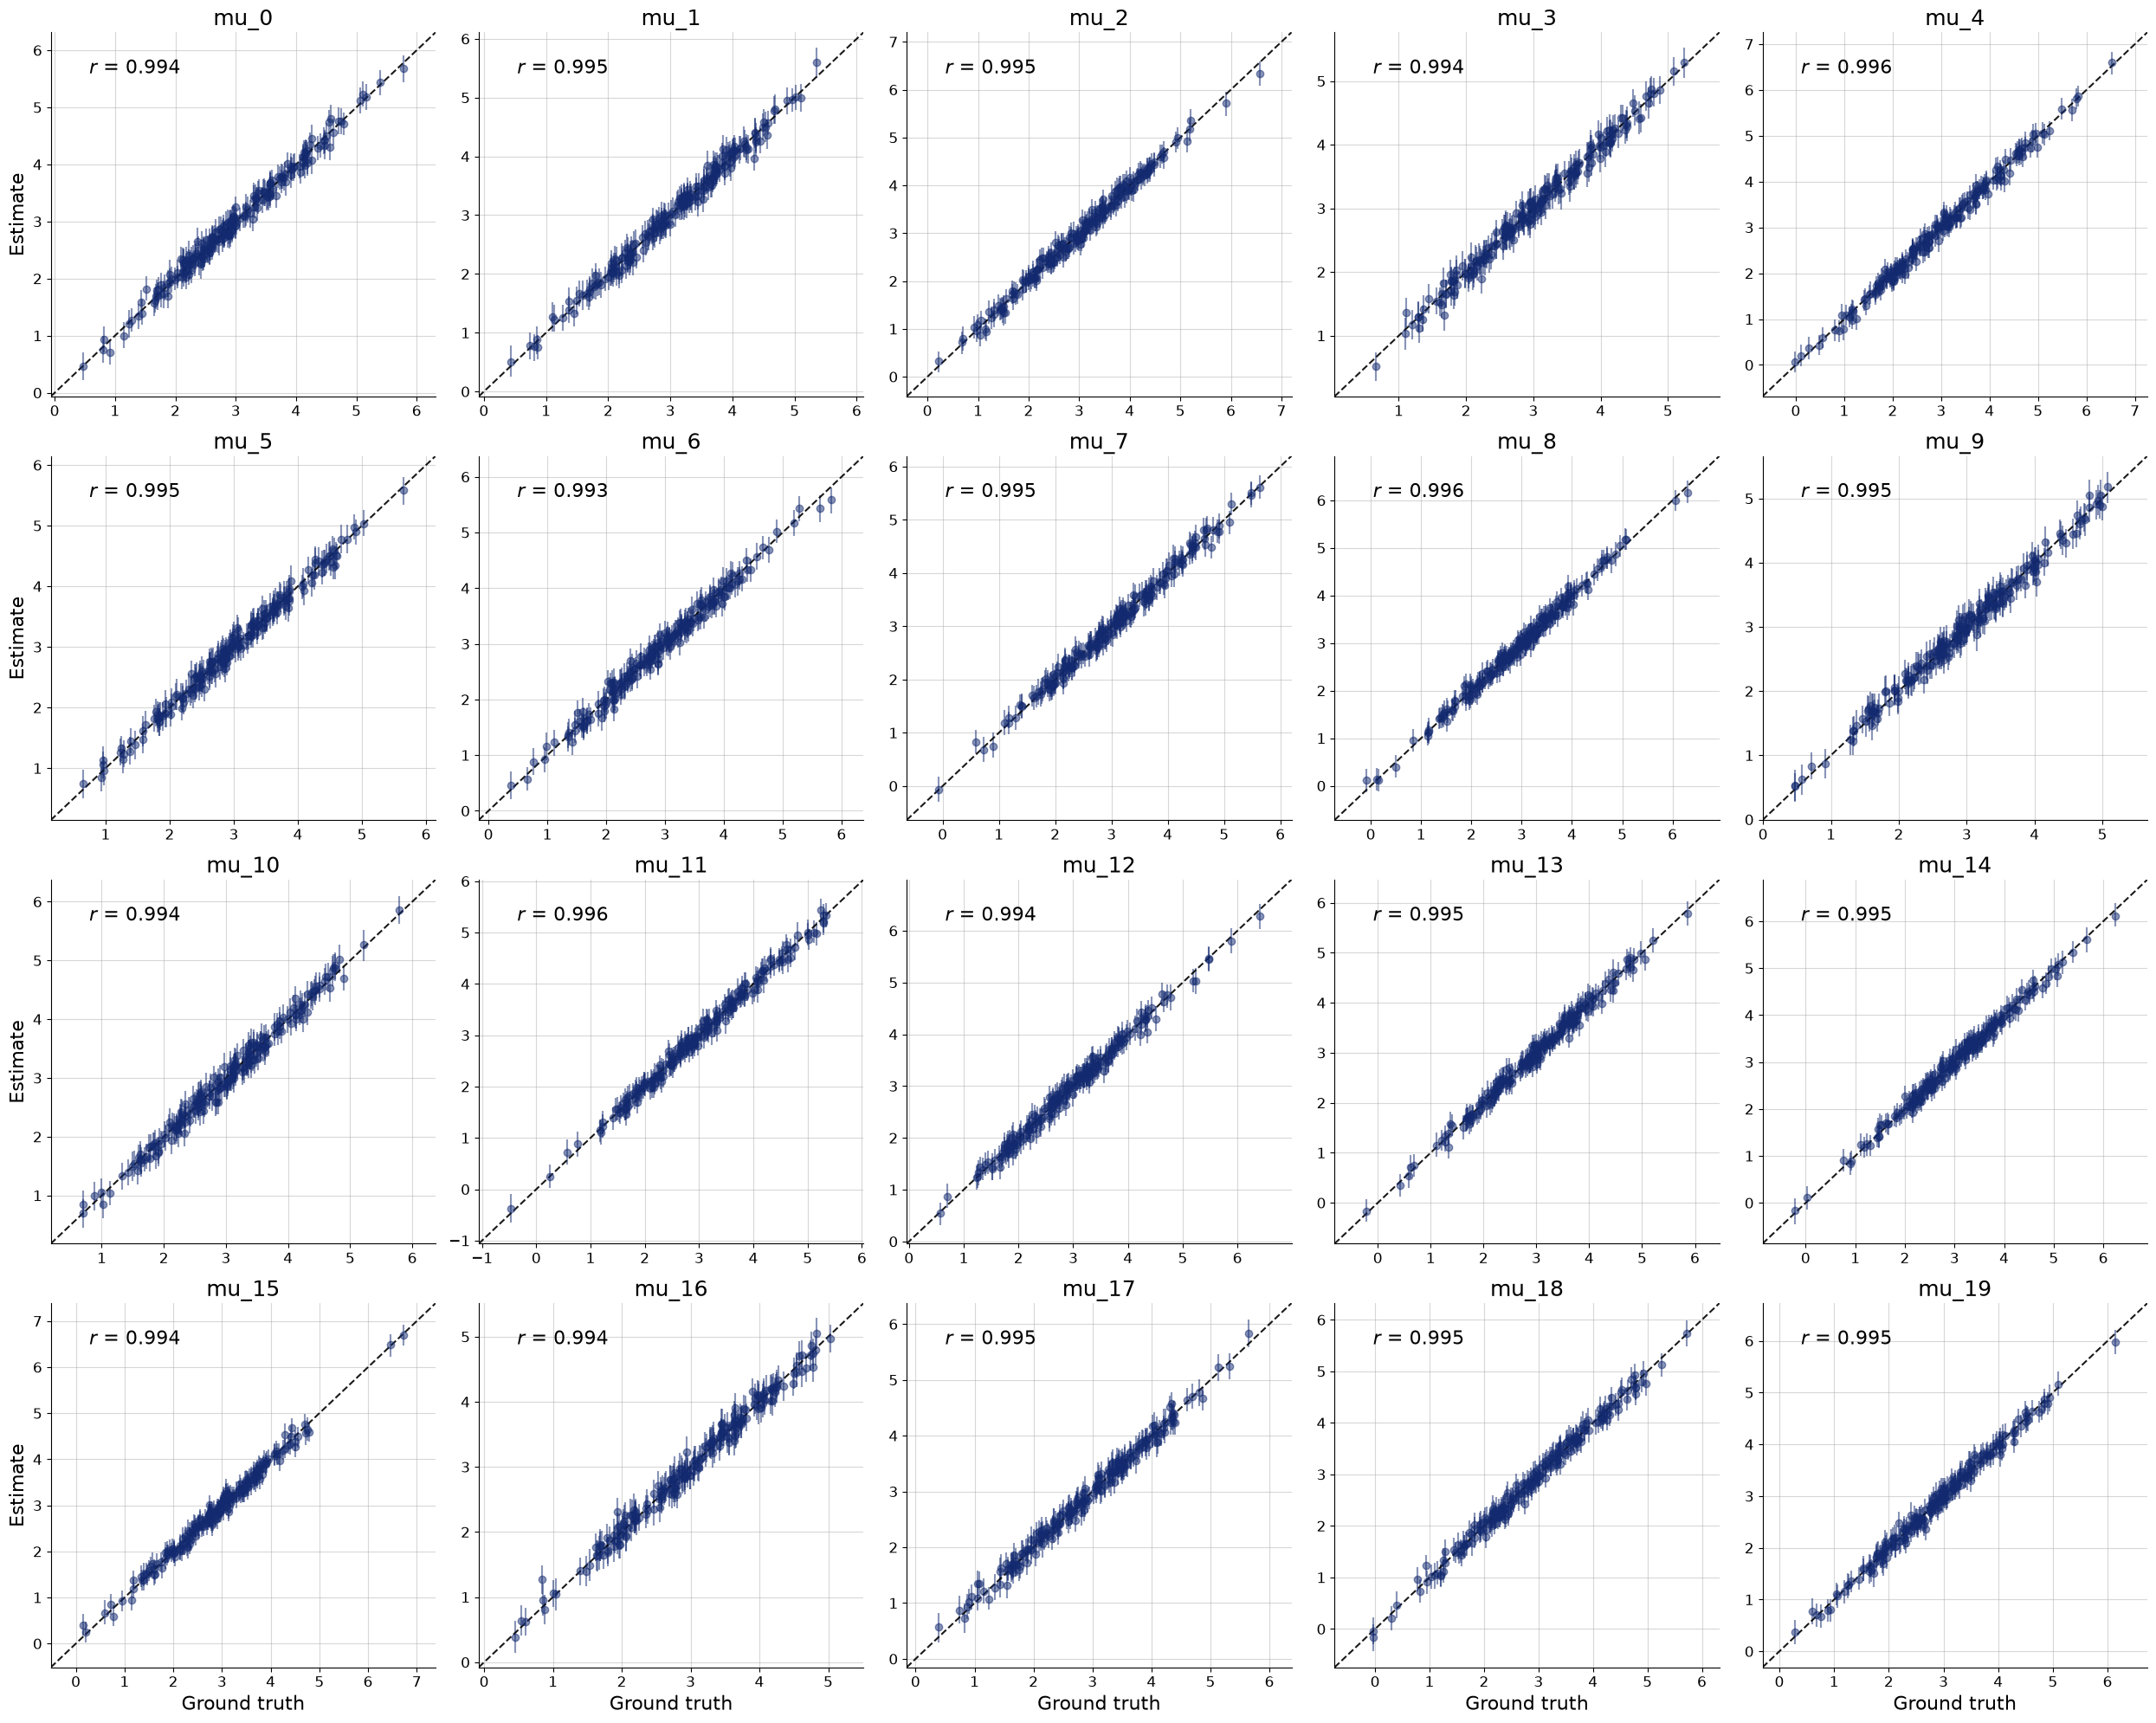

In [14]:
post_draws = approximator.sample(conditions=val_sims, num_samples=num_samples)
f3 = bf.diagnostics.plots.recovery(post_draws, val_sims)